In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import re
import matplotlib 
import matplotlib as mpl
from pathlib import Path

In [2]:
driver = "vGAT"
responder = "eOPN3_ATR"

laptop = "C:\\Users\\lnico"
workcomp = "C:\\Users\\User"
homecomp = "D:"
base_path = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\2. Processed\\"  
titledpath = homecomp
specifiedpath = titledpath + base_path

bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
maxtime = 3600
specifictime = 200  # for shorter time plots (seconds)

#'ActivityLevel' or 'Speed'
metric_to_plot = 'Speed'

In [3]:
# Set up Inter font
inter_font_path = titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

## Opsin comparison

In [24]:
driver = "elav"
specifictime = 121
opsin_files = {
    'elav control': specifiedpath + "w1118 x elav_ATR_5s",
    'AsOPN3 control': specifiedpath + "w1118 x eOPN3_5s",
    'AsOPN3* control': specifiedpath + "w1118 x eOPN3_ATR_5s"

}

# opsin_files = {
#     'ACR*': specifiedpath + "elav x ACR_5s",
#     'AsOPN3': specifiedpath + "elav x eOPN3_5s",
#     'AsOPN3*': specifiedpath + "elav x eOPN3_ATR_5s"

# }

opsin_title = "opsin_wt"

In [25]:
opsin_data = {}

for label, filepath in opsin_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  
    opsin_data[label] = df.filter(regex="^" + metric_to_plot).T.reset_index(drop=True)

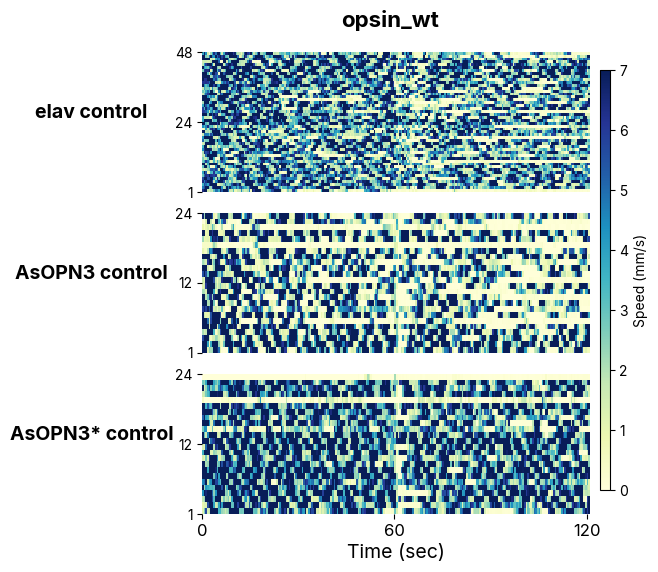

In [26]:
num_conditions = len(opsin_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(5, 6), sharex=True)
plt.subplots_adjust(hspace=0.15)
cmaps = "YlGnBu"
if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"

vmax_number = 7

for idx, (label, data) in enumerate(opsin_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]
    
    hm = sns.heatmap(data, cmap=cmaps, cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=vmax_number, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=60, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')


last_data = list(opsin_data.values())[-1]
tick_times = [0, 60, specifictime - 1]
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)


cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmaps, norm=plt.Normalize(vmin=0, vmax=vmax_number))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(opsin_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\" + metric_to_plot + "_" + opsin_title +".svg", bbox_inches='tight')

## Stacked by Illumination Duration

In [37]:
driver = "elav"
responder = "eOPN3_ATR"
specifictime = 361
duration_files = {
    '0s': specifiedpath + driver + " x " + responder + "_0s",
    '5s': specifiedpath + driver + " x " + responder + "_5s",
    '30s': specifiedpath + driver + " x " + responder + "_30s",
    '60s': specifiedpath + driver + " x " + responder + "_60s",
}

duration_plot_title = driver + " > " + responder + " - Illumination Duration"

In [38]:
duration_data = {}

split_map = {'0s': 'odd', '5s': 'odd'}

for label, filepath in duration_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  # trim to specifictime
    cols = sorted([c for c in df.columns if c.startswith(metric_to_plot)], key=lambda c: int(c.split('_')[1]))
    split = split_map.get(label)
    if split == 'even':
        cols = cols[1::2]
    elif split == 'odd':
        cols = cols[0::2]
    duration_data[label] = df[cols].T.reset_index(drop=True)

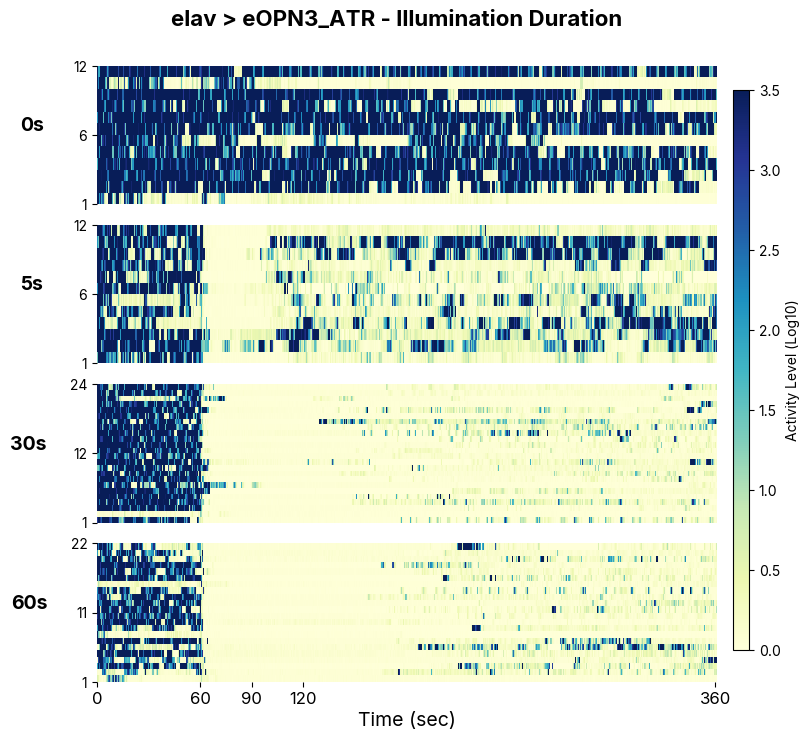

In [52]:
num_conditions = len(duration_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(8,8), sharex=True) #for elav
#fig, axes = plt.subplots(num_conditions, 1, figsize=(6, 2*num_conditions), sharex=True) #for vgat
plt.subplots_adjust(hspace=0.15)
cmaps = "YlGnBu"

metric_to_plot = 'ActivityLevel'

if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
    vmax_number = 3.5
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"
    vmax_number = 7
for idx, (label, data) in enumerate(duration_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]


    hm = sns.heatmap(data, cmap=cmaps, cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=vmax_number, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=30, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')


last_data = list(duration_data.values())[-1]
# tick_times = list(range(0, int(specifictime), int(specifictime/10)))
tick_times = [0, 60, 90, 120, specifictime - 1]
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)


cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmaps, norm=plt.Normalize(vmin=0, vmax=vmax_number))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(duration_plot_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

plt.savefig(titledpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\" + metric_to_plot + "_" + driver + "_" + responder + ".svg", bbox_inches='tight')

## Stacked by Light Intensity

In [53]:
specifictime = 361

intensity_files = {
    'No Light': specifiedpath + driver + " x " + responder + "_0s",
    'Quarter': specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half': specifiedpath + driver + " x " + responder + "_half_5s",
    'Full': specifiedpath + driver + " x " + responder + "_5s",
}

intensity_plot_title = driver + " > " + responder + " - Light Intensity"

In [54]:
intensity_data = {}

split_map = {'No Light': 'even', 'Full': 'even'}

for label, filepath in intensity_files.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]  # trim to specifictime
    cols = sorted([c for c in df.columns if c.startswith(metric_to_plot)], key=lambda c: int(c.split('_')[1]))
    split = split_map.get(label)
    if split == 'even':
        cols = cols[1::2]
    elif split == 'odd':
        cols = cols[0::2]
    intensity_data[label] = df[cols].T.reset_index(drop=True)

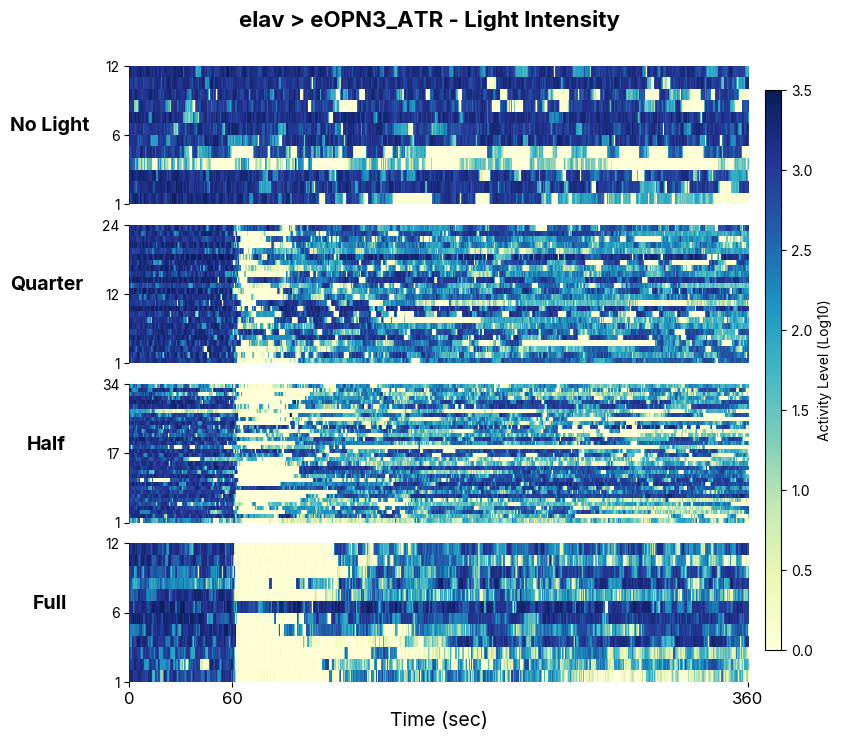

In [55]:
num_conditions = len(intensity_data)
fig, axes = plt.subplots(num_conditions, 1, figsize=(8, 8), sharex=True) #for elav
#fig, axes = plt.subplots(num_conditions, 1, figsize=(6, 2*num_conditions), sharex=True) #for vgat
plt.subplots_adjust(hspace=0.15)

cmaps = "YlGnBu"

if metric_to_plot == "ActivityLevel":
    scalebar_label = "Activity Level (Log10)"
    vmax_number = 3.5
elif metric_to_plot == "Speed":
    scalebar_label = "Speed (mm/s)"
    vmax_number = 7
for idx, (label, data) in enumerate(intensity_data.items()):
    ax = axes[idx]
    num_flies = data.shape[0]
    
    hm = sns.heatmap(data, cmap=cmaps, cbar=False, xticklabels=False, yticklabels=False, 
                     vmin=0, vmax=vmax_number, ax=ax)
    quadmesh = ax.collections[0]
    quadmesh.set_rasterized(True)
    quadmesh.set_edgecolor('face')
    quadmesh.set_linewidth(0)
    
    ax.set_ylabel(label, rotation=0, labelpad=40, fontsize=14, weight='bold')
    ax.set_yticks([0, num_flies//2, num_flies])
    ticklabels = [num_flies, (num_flies+1)//2, 1]
    ax.set_yticklabels(ticklabels, fontsize=10)
    
    if idx < num_conditions - 1:
        ax.tick_params(axis='x', bottom=False)
        ax.set_xlabel('')
    ax.patch.set_facecolor('white')

last_data = list(intensity_data.values())[-1]
# tick_times = list(range(20, int(specifictime), int(specifictime/10)))
tick_times = [0, 60, specifictime - 1]
tick_positions = [list(last_data.columns).index(float(t)) for t in tick_times if float(t) in last_data.columns]
axes[-1].set_xticks(tick_positions)
axes[-1].set_xticklabels(tick_times, rotation=0, fontsize=12)
axes[-1].set_xlabel("Time (sec)", fontsize=14)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmaps, norm=plt.Normalize(vmin=0, vmax=vmax_number))
fig.colorbar(sm, cax=cbar_ax, label=scalebar_label)

fig.suptitle(intensity_plot_title, weight="bold", fontsize=16, y=0.95)

mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')

plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\light_intensity_speed" + driver + "_" + responder + ".svg", bbox_inches='tight')

## Line Graphs

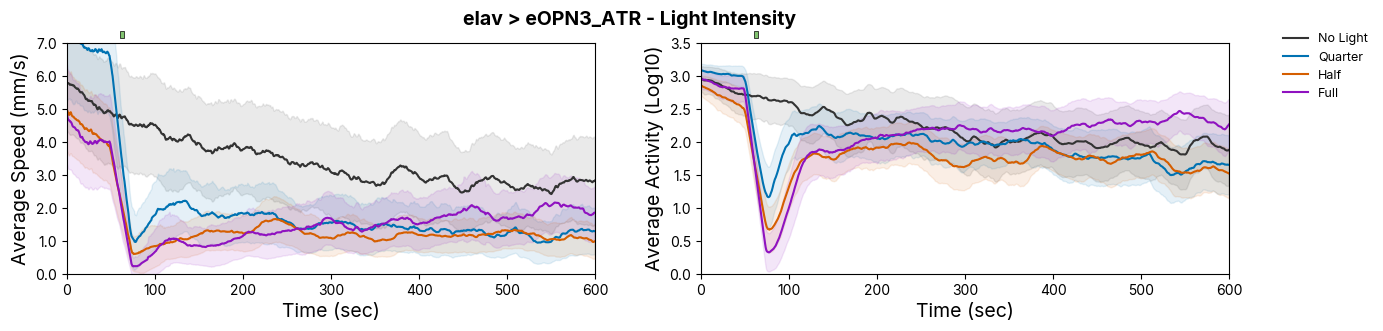

In [84]:
driver = "elav"
responder = "eOPN3_ATR"
# driver = "w1118"
specifictime = 600

line_colors = {
    'No Light': "#333333",
    'Quarter': "#0072B2",
    'Half': "#D55E00",
    'Full':  "#8F12C0"
}

intensity_files_line = {
    'No Light': specifiedpath + driver + " x " + responder + "_0s",
    'Quarter': specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half': specifiedpath + driver + " x " + responder + "_half_5s",
    'Full': specifiedpath + driver + " x " + responder + "_5s",
}

rolling_window = 50
intensity_speed = {}
intensity_activity = {}

for label, filepath in intensity_files_line.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]

    speed_df = df.filter(regex="^Speed").T.reset_index(drop=True)
    activity_df = df.filter(regex="^ActivityLevel").T.reset_index(drop=True)

    intensity_speed[label] = speed_df
    intensity_activity[label] = activity_df

fig, axes = plt.subplots(1, 2, figsize=(15,3), gridspec_kw={'wspace': 0.2})
plt.subplots_adjust(hspace=0.1)


ax_speed = axes[0]
for label, data in intensity_speed.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_speed.plot(time, mean_vals, color=line_colors[label], label=label, linewidth=1.5)
    ax_speed.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors[label], alpha=0.1)

ax_speed.set_ylabel("Average Speed (mm/s)", fontsize=14)
ax_speed.set_xlabel("Time (sec)", fontsize=14)
ax_speed.set_yticks([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
ax_speed.set_yticklabels([f'{t:.1f}' for t in range(8)])
ax_speed.set_ylim(0.0, 7.0)


ax_activity = axes[1]
for label, data in intensity_activity.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_activity.plot(time, mean_vals, color=line_colors[label], label=label, linewidth=1.5)
    ax_activity.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors[label], alpha=0.1)

ax_activity.set_ylabel("Average Activity (Log10)", fontsize=14)
ax_activity.set_xlabel("Time (sec)", fontsize=14)
ax_activity.set_yticks(np.arange(0, 4.0, 0.5))
ax_activity.set_ylim(0, 3.5)

#legend
handles, labels = ax_activity.get_legend_handles_labels()
fig.legend (handles, labels, loc = "upper right", bbox_to_anchor = (1.0, 0.95), frameon = False, fontsize = 9)
from matplotlib.patches import Rectangle
for ax in axes:
    ymax = ax.get_ylim()[1]
    bar_y = ymax * 1.02  # just above the plot
    bar_h = ymax * 0.03  # bar thickness
    
    ax.add_patch(Rectangle((60, ymax * 1.02), 5, bar_h, facecolor="#1E94018F", edgecolor='black', linewidth=0.5, clip_on=False))
    ax.set_xlim(0, 600)
    ax.set_xticks(np.arange(0, 601, 100))
    
fig.suptitle(driver + " > " + responder + " - Light Intensity", weight="bold", fontsize=14, y=0.99)
mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')
plt.tight_layout(rect=[0, 0, 0.98, 1])


#plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\lineplot_intensity" + driver + "_" + responder + ".svg", bbox_inches='tight')

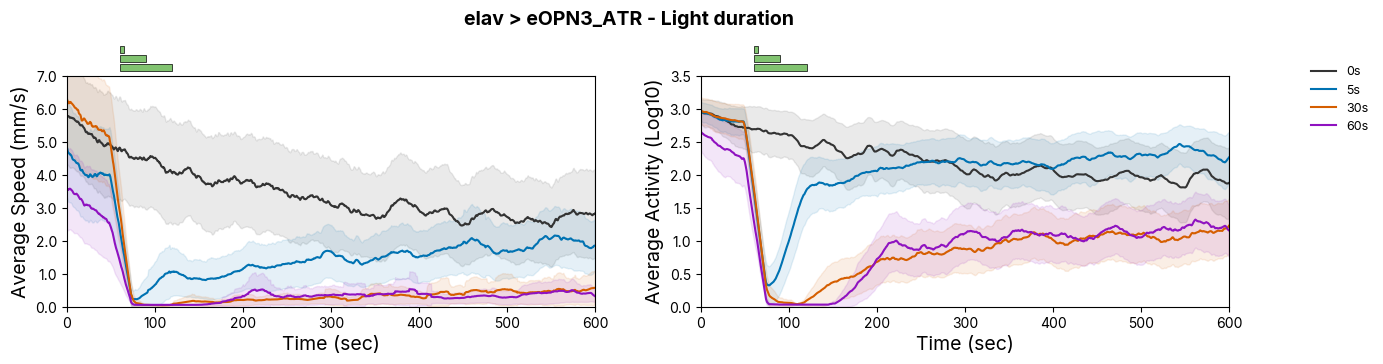

In [85]:
driver = "elav"
responder = "eOPN3_ATR"
#driver = "w1118"
specifictime = 600

line_colors = {
    '0s': "#333333",
    '5s': "#0072B2",
    '30s': "#D55E00",
    '60s':  "#8F12C0"
}

duration_files_line = {
    '0s': specifiedpath + driver + " x " + responder + "_0s",
    '5s': specifiedpath + driver + " x " + responder + "_5s",
    '30s': specifiedpath + driver + " x " + responder + "_30s",
    '60s': specifiedpath + driver + " x " + responder + "_60s",
}

rolling_window = 50
duration_speed = {}
duration_activity = {}

for label, filepath in duration_files_line.items():
    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    df = df.iloc[0:(specifictime*2), :]

    speed_df = df.filter(regex="^Speed").T.reset_index(drop=True)
    activity_df = df.filter(regex="^ActivityLevel").T.reset_index(drop=True)

    duration_speed[label] = speed_df
    duration_activity[label] = activity_df

fig, axes = plt.subplots(1, 2, figsize=(15,3), gridspec_kw={'wspace': 0.2})
plt.subplots_adjust(hspace=0.1)


ax_speed = axes[0]
for label, data in duration_speed.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_speed.plot(time, mean_vals, color=line_colors[label], label=label, linewidth=1.5)
    ax_speed.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors[label], alpha=0.1)

ax_speed.set_ylabel("Average Speed (mm/s)", fontsize=14)
ax_speed.set_xlabel("Time (sec)", fontsize=14)
ax_speed.set_yticks([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
ax_speed.set_yticklabels([f'{t:.1f}' for t in range(8)])
ax_speed.set_ylim(0.0, 7.0)


ax_activity = axes[1]
for label, data in duration_activity.items():
    time = data.columns.values
    mean_vals = data.mean(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    sem_vals = data.sem(axis=0).rolling(window=rolling_window, center=True, min_periods=1).mean()
    ci = 1.96 * sem_vals

    ax_activity.plot(time, mean_vals, color=line_colors[label], label=label, linewidth=1.5)
    ax_activity.fill_between(time, mean_vals - ci, mean_vals + ci, color=line_colors[label], alpha=0.1)

ax_activity.set_ylabel("Average Activity (Log10)", fontsize=14)
ax_activity.set_xlabel("Time (sec)", fontsize=14)
ax_activity.set_yticks(np.arange(0, 4.0, 0.5))
ax_activity.set_ylim(0, 3.5)

#legend
handles, labels = ax_activity.get_legend_handles_labels()
fig.legend (handles, labels, loc = "upper right", bbox_to_anchor = (1.0, 0.95), frameon = False, fontsize = 9)

from matplotlib.patches import Rectangle
for ax in axes:
    ax.set_xlim(0, 600)
    ax.set_xticks(np.arange(0, 601, 100))
    
    ymax = ax.get_ylim()[1]
    bar_y = ymax * 1.02  # just above the plot
    bar_h = ymax * 0.03  # bar thickness
    
    ax.add_patch(Rectangle((60, ymax * 1.02), 60, bar_h, facecolor="#1E94018F", edgecolor='black', linewidth=0.5, clip_on=False))
    ax.add_patch(Rectangle((60, ymax * 1.06), 30, bar_h, facecolor='#1E94018F', edgecolor='black', linewidth=0.5, clip_on=False))
    ax.add_patch(Rectangle((60, ymax * 1.10), 5,  bar_h, facecolor='#1E94018F', edgecolor='black', linewidth=0.5, clip_on=False))
    
fig.suptitle(driver + " > " + responder + " - Light duration", weight="bold", fontsize=14, y=1.1)
mpl.rcParams['svg.fonttype'] = 'none'
fig.patch.set_facecolor('white')
plt.tight_layout(rect=[0, 0, 0.98, 1])


#plt.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\lineplot_duration" + driver + "_" + responder + ".svg", bbox_inches='tight')

## Dabest

In [75]:
def get_phases(light_duration_s=5.0):
    baseline = 60 * 2
    light_dur = light_duration_s * 2
    light_off = baseline + light_dur

    first_phase = slice(0, baseline - 0.5)
    light_on = slice(baseline, baseline + light_dur - 0.5)
    first_min = slice(light_off, light_off + 120 - 0.5)
    third_min = slice(light_off + 240, light_off + 360 - 0.5)
    fifth_min = slice(light_off + 480, light_off + 600 - 0.5)

    return first_phase, light_on, first_min, third_min, fifth_min

def load_and_split(filepath, phase_slice, split=None):
    df = pd.read_csv(filepath + "_max3600s.csv").set_index('Time (s)')
    df = df.loc[phase_slice, :]
    speed_cols = sorted([c for c in df.columns if c.startswith('Speed')], key=lambda c: int(c.split('_')[1]))
    activity_cols = sorted([c for c in df.columns if c.startswith('ActivityLevel')], key=lambda c: int(c.split('_')[1]))
    if split == 'even':
        speed_cols = speed_cols[1::2]
        activity_cols = activity_cols[1::2]
    elif split == 'odd':
        speed_cols = speed_cols[0::2]
        activity_cols = activity_cols[0::2]
    return df[speed_cols].T.reset_index(drop=True), df[activity_cols].T.reset_index(drop=True)

In [76]:
driver = "elav"
responder = "eOPN3_ATR"
w1118 = "w1118"
both_controls = "No"

first_phase, light_on, first_min, third_min, fifth_min = get_phases(5.0)

ctrl_speed_nolight, ctrl_activity_nolight = load_and_split(specifiedpath + w1118 + " x " + responder + "_0s", first_min, 'even')
ctrl_speed_full, ctrl_activity_full = load_and_split(specifiedpath + driver + " x " + responder + "_0s", first_min, 'even')

if both_controls == "Yes":
    drv_speed_nolight, drv_activity_nolight = load_and_split(specifiedpath + w1118 + " x " + driver + "_ATR_0s", first_min, 'even')
    ctrl_speed_nolight = pd.concat([ctrl_speed_nolight, drv_speed_nolight], ignore_index=True)
    ctrl_activity_nolight = pd.concat([ctrl_activity_nolight, drv_activity_nolight], ignore_index=True)

all_speed = [ctrl_speed_nolight.mean(axis=1), ctrl_speed_full.mean(axis=1)]
all_activity = [ctrl_activity_nolight.mean(axis=1), ctrl_activity_full.mean(axis=1)]
all_labels = ['No Light_control', 'Full_control']

intensity_files = {
    'Quarter_control': (specifiedpath + w1118 + " x " + responder + "_quarter_5s", None),
    'Half_control': (specifiedpath + w1118 + " x " + responder + "_half_5s", None),
    'No Light_expt': (specifiedpath + driver + " x " + responder + "_0s", 'even'),
    'Quarter_expt': (specifiedpath + driver + " x " + responder + "_quarter_5s", None),
    'Half_expt': (specifiedpath + driver + " x " + responder + "_half_5s", None),
    'Full_expt': (specifiedpath + driver + " x " + responder + "_5s", 'even'),
}

for label, (filepath, split) in intensity_files.items():
    speed_df, activity_df = load_and_split(filepath, first_min, split)
    all_speed.append(speed_df.mean(axis=1))
    all_activity.append(activity_df.mean(axis=1))
    all_labels.append(label)

df_dabest_speed = pd.concat(all_speed, axis=1, ignore_index=True)
df_dabest_speed.columns = all_labels
df_dabest_activity = pd.concat(all_activity, axis=1, ignore_index=True)
df_dabest_activity.columns = all_labels

phase = "1st_min"

In [77]:
import dabest

db_speed_3 = dabest.load(df_dabest_speed, idx=(("No Light_control", "No Light_expt", "Quarter_expt",  "Half_expt", "Full_expt")))
db_activitylevel_3 = dabest.load(df_dabest_activity, idx=(("No Light_control", "No Light_expt", "Quarter_expt",  "Half_expt", "Full_expt")))

c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 12.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 29.4% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 8.3% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 29.2% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 20.6% of the points cannot be placed. You 

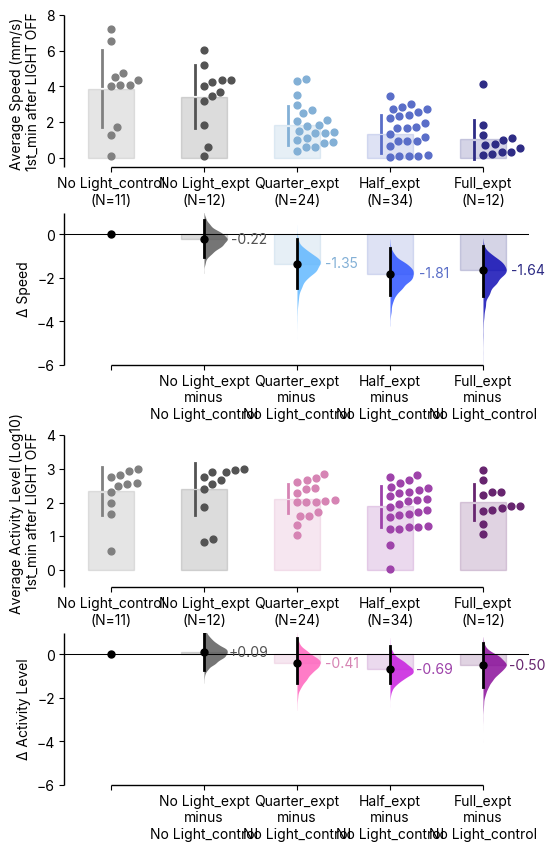

In [79]:

colorpalette = ["gray", "#535353",  "#59B4FF",  "#234BFF",  "#0300B1" ]
colorpalette_2 = ["gray", "#535353",  "#FF5BBA",  "#C510DD",  "#830094"]

f, axx = plt.subplots(2,1, figsize = (6,10))
common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}


db_speed_3.hedges_g.plot(raw_label=f"Average Speed (mm/s) \n"  + str(phase) + " after LIGHT OFF", custom_palette = colorpalette,
                              contrast_label="Î” Speed", raw_ylim=(-0.5, 8), contrast_ylim=(-6, 1),  **common_style, ax = axx[0]);



db_activitylevel_3.hedges_g.plot(raw_label=f"Average Activity Level (Log10) \n"  + str(phase) + " after LIGHT OFF", custom_palette = colorpalette_2,
                              contrast_label="Î” Activity Level", raw_ylim=(-0.5, 4), contrast_ylim=(-6, 1),  **common_style, ax = axx[1]);
mpl.rcParams['svg.fonttype'] = 'none'
f.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\dabestplots_compiledplot_" + driver + " x " + responder + ".svg",  bbox_inches='tight')


In [80]:
driver = "elav"
responder = "eOPN3_ATR"
w1118 = "w1118"
both_controls = "No"

_, _, first_min_0s, _, _ = get_phases(60)

ctrl_speed_0s, ctrl_activity_0s = load_and_split(specifiedpath + w1118 + " x " + responder + "_0s", first_min_0s, 'odd')
expt_speed_0s, expt_activity_0s = load_and_split(specifiedpath + driver + " x " + responder + "_0s", first_min_0s, 'odd')

if both_controls == "Yes":
    drv_speed_0s, drv_activity_0s = load_and_split(specifiedpath + w1118 + " x " + driver + "_ATR_0s", first_min_0s, 'odd')
    ctrl_speed_0s = pd.concat([ctrl_speed_0s, drv_speed_0s], ignore_index=True)
    ctrl_activity_0s = pd.concat([ctrl_activity_0s, drv_activity_0s], ignore_index=True)

all_speed = [ctrl_speed_0s.mean(axis=1), expt_speed_0s.mean(axis=1)]
all_activity = [ctrl_activity_0s.mean(axis=1), expt_activity_0s.mean(axis=1)]
all_labels = ['0s_control', '0s_expt']

duration_files = {
    '5s_control': (specifiedpath + w1118 + " x " + responder + "_5s", None),
    '30s_control': (specifiedpath + w1118 + " x " + responder + "_30s", None),
    '60s_control': (specifiedpath + w1118 + " x " + responder + "_60s", None),
    '5s_expt': (specifiedpath + driver + " x " + responder + "_5s", 'odd'),
    '30s_expt': (specifiedpath + driver + " x " + responder + "_30s", None),
    '60s_expt': (specifiedpath + driver + " x " + responder + "_60s", None),
}

for label, (filepath, split) in duration_files.items():
    duration = int(label.split('s_')[0])
    first_phase, light_on, first_min, third_min, fifth_min = get_phases(duration)
    speed_df, activity_df = load_and_split(filepath, first_min, split)
    all_speed.append(speed_df.mean(axis=1))
    all_activity.append(activity_df.mean(axis=1))
    all_labels.append(label)

df_dabest_speed = pd.concat(all_speed, axis=1, ignore_index=True)
df_dabest_speed.columns = all_labels
df_dabest_activity = pd.concat(all_activity, axis=1, ignore_index=True)
df_dabest_activity.columns = all_labels

phase = "1st_min"

In [81]:
db_speed_2 = dabest.load(df_dabest_speed, idx=("0s_control", "0s_expt", "5s_expt", "30s_expt", "60s_expt"))
db_activitylevel_2 = dabest.load(df_dabest_activity, idx=(("0s_control", "0s_expt", "5s_expt",  "30s_expt", "60s_expt")))

c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 62.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 59.1% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\_effsize_objects.py:311: UserWarning: The upper limit of the interval was in the top 10 values. The result should be considered unstable.
  warnings.warn(
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 4.2% of the points 

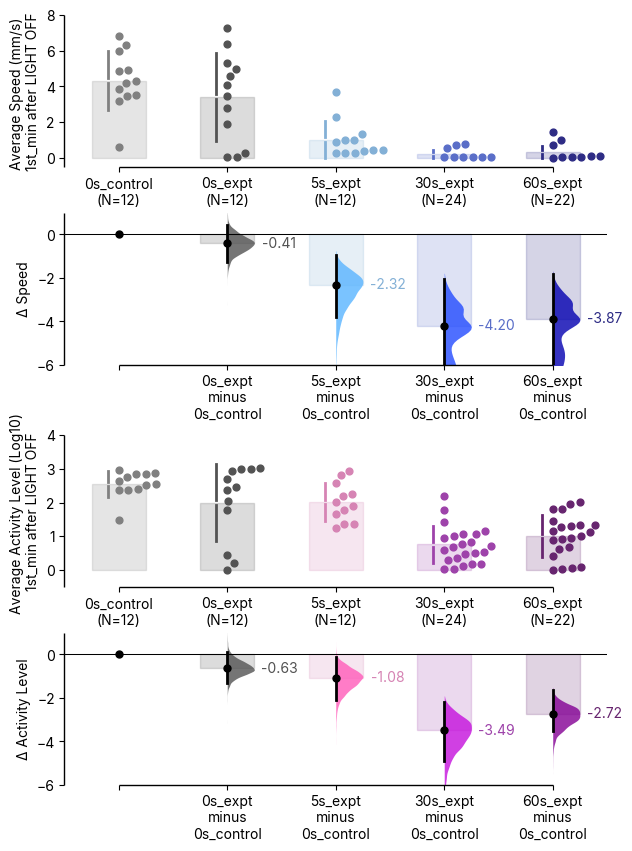

In [82]:

colorpalette = ["gray", "#535353",  "#59B4FF",  "#234BFF",  "#0300B1" ]
colorpalette_2 = ["gray", "#535353",  "#FF5BBA",  "#C510DD",  "#830094"]

f, axx = plt.subplots(2,1, figsize = (7,10))
common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

db_speed_2.hedges_g.plot(raw_label=f"Average Speed (mm/s) \n"  + str(phase) + " after LIGHT OFF", custom_palette = colorpalette,
                              contrast_label="Î” Speed", raw_ylim=(-0.5, 8), contrast_ylim=(-6, 1),  **common_style, ax = axx[0]);

db_activitylevel_2.hedges_g.plot(raw_label=f"Average Activity Level (Log10) \n"  + str(phase) + " after LIGHT OFF", custom_palette = colorpalette_2,
                              contrast_label="Î” Activity Level", raw_ylim=(-0.5, 4), contrast_ylim=(-6, 1),  **common_style, ax = axx[1]);

mpl.rcParams['svg.fonttype'] = 'none'
f.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\dabestplots_compiledplot_duration" + driver + " x " + responder + ".svg",  bbox_inches='tight')


## dabest paired plot

In [488]:
driver = "elav"
responder = "eOPN3_ATR"

intensity_paired_files = {
    'No Light': (specifiedpath + driver + " x " + responder + "_0s", 5),
    'Quarter': (specifiedpath + driver + " x " + responder + "_quarter_5s", 5),
    'Half': (specifiedpath + driver + " x " + responder + "_half_5s", 5),
    'Full': (specifiedpath + driver + " x " + responder + "_5s", 5),
}

baseline = 60 * 2
phase_labels = ['baseline', 'light_on', '0-30s', '30-60s', '60-90s', '90-120s']

intensity_paired_speed = pd.DataFrame()
intensity_paired_activity = pd.DataFrame()

for label, (filepath, light_duration_s) in intensity_paired_files.items():
    light_dur = light_duration_s * 2
    light_off = baseline + light_dur

    phases = [
        slice(0, baseline - 0.5),
        slice(baseline, light_off - 0.5),
        slice(light_off, light_off + 60 - 0.5),
        slice(light_off + 60, light_off + 120 - 0.5),
        slice(light_off + 120, light_off + 180 - 0.5),
        slice(light_off + 180, light_off + 240 - 0.5),
    ]

    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')

    df_speed_paired = pd.DataFrame()
    df_activity_paired = pd.DataFrame()

    for phase_slice, pl in zip(phases, phase_labels):
        phase_df = df.loc[phase_slice, :]

        speed_vals = phase_df.filter(regex="^Speed").T.reset_index(drop=True)
        activity_vals = phase_df.filter(regex="^ActivityLevel").T.reset_index(drop=True)

        df_speed_paired[label + "_" + pl] = speed_vals.mean(axis=1)
        df_activity_paired[label + "_" + pl] = activity_vals.mean(axis=1)

    intensity_paired_speed = pd.concat([intensity_paired_speed, df_speed_paired], axis=1)
    intensity_paired_activity = pd.concat([intensity_paired_activity, df_activity_paired], axis=1)

intensity_paired_speed = intensity_paired_speed.reset_index(drop=True)
intensity_paired_speed['ID'] = intensity_paired_speed.index

intensity_paired_activity = intensity_paired_activity.reset_index(drop=True)
intensity_paired_activity['ID'] = intensity_paired_activity.index

In [489]:
db_speed = dabest.load(intensity_paired_speed,
                        idx=(('No Light_baseline','No Light_light_on','No Light_0-30s','No Light_30-60s','No Light_60-90s','No Light_90-120s'),
                             ('Quarter_baseline','Quarter_light_on','Quarter_0-30s','Quarter_30-60s','Quarter_60-90s','Quarter_90-120s'),
                             ('Half_baseline','Half_light_on','Half_0-30s','Half_30-60s','Half_60-90s','Half_90-120s'),
                             ('Full_baseline','Full_light_on','Full_0-30s','Full_30-60s','Full_60-90s','Full_90-120s')),
                        paired="baseline", id_col="ID")

db_activity = dabest.load(intensity_paired_activity,
                            idx=(('No Light_baseline','No Light_light_on','No Light_0-30s','No Light_30-60s','No Light_60-90s','No Light_90-120s'),
                             ('Quarter_baseline','Quarter_light_on','Quarter_0-30s','Quarter_30-60s','Quarter_60-90s','Quarter_90-120s'),
                             ('Half_baseline','Half_light_on','Half_0-30s','Half_30-60s','Half_60-90s','Half_90-120s'),
                             ('Full_baseline','Full_light_on','Full_0-30s','Full_30-60s','Full_60-90s','Full_90-120s')),
                            paired="baseline", id_col="ID")

c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\_dabest_object.py:564: UserWarning: NaN values detected under paired setting and removed, please check your data.
  warnings.warn(warn1 + warn2)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\_dabest_object.py:564: UserWarning: NaN values detected under paired setting and removed, please check your data.
  warnings.warn(warn1 + warn2)


In [490]:
db_speed_2 = dabest.load(intensity_paired_speed,
                        idx=(('No Light_baseline', 'Quarter_baseline', 'Half_baseline', 'Full_baseline'),
                             ('No Light_light_on', 'Quarter_light_on', 'Half_light_on', 'Full_light_on'),
                             ('No Light_0-30s', 'Quarter_0-30s', 'Half_0-30s', 'Full_0-30s'),
                             ('No Light_30-60s', 'Quarter_30-60s', 'Half_30-60s', 'Full_30-60s'),
                             ('No Light_60-90s', 'Quarter_60-90s', 'Half_60-90s', 'Full_60-90s'),
                             ('No Light_90-120s', 'Quarter_90-120s', 'Half_90-120s', 'Full_90-120s')),
                        id_col="ID")

db_activity_2 = dabest.load(intensity_paired_activity,
                            idx=(('No Light_baseline', 'Quarter_baseline', 'Half_baseline', 'Full_baseline'),
                             ('No Light_light_on', 'Quarter_light_on', 'Half_light_on', 'Full_light_on'),
                             ('No Light_0-30s', 'Quarter_0-30s', 'Half_0-30s', 'Full_0-30s'),
                             ('No Light_30-60s', 'Quarter_30-60s', 'Half_30-60s', 'Full_30-60s'),
                             ('No Light_60-90s', 'Quarter_60-90s', 'Half_60-90s', 'Full_60-90s'),
                             ('No Light_90-120s', 'Quarter_90-120s', 'Half_90-120s', 'Full_90-120s')),
                            id_col="ID")

c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 8.3% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 12.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 23.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 16.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 12.5% of the points cannot be placed. You 

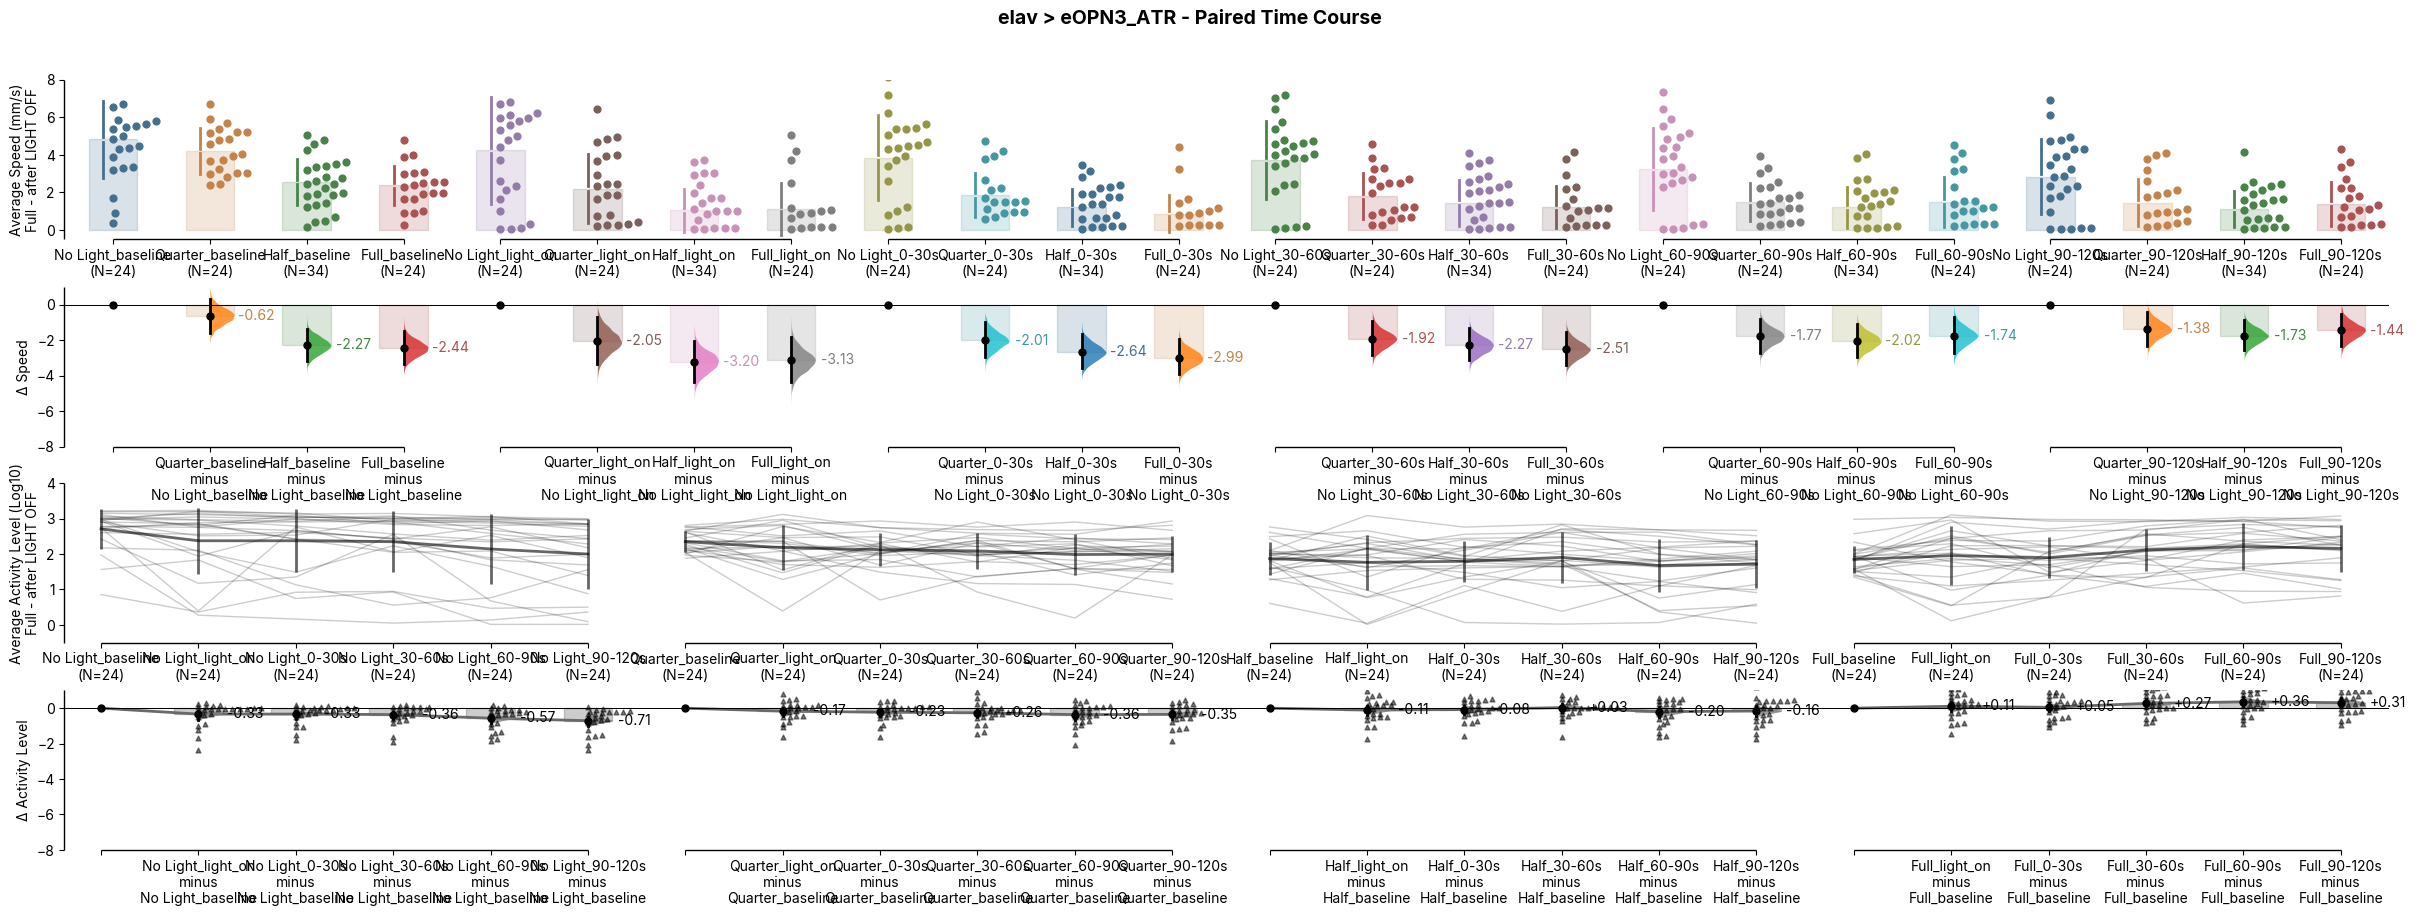

In [493]:

# Paired plots - intensity
common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

f, axx = plt.subplots(2, 1, figsize=(30, 10), gridspec_kw={'hspace':0.1})
db_speed_2.mean_diff.plot(raw_label=f"Average Speed (mm/s)\n{label} - after LIGHT OFF",
                        contrast_label="Î” Speed", raw_ylim=(-0.5, 8), contrast_ylim=(-8, 1),
                        **common_style, ax=axx[0])

db_activity.mean_diff.plot(raw_label=f"Average Activity Level (Log10)\n{label} - after LIGHT OFF",
                            contrast_label="Î” Activity Level", raw_ylim=(-0.5, 4), contrast_ylim=(-8, 1),
                            **common_style, ax=axx[1])

f.suptitle(f"{driver} > {responder} - Paired Time Course", weight="bold", fontsize=14, y=0.95)
mpl.rcParams['svg.fonttype'] = 'none'
plt.tight_layout()
#f.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\dabest_paired_intensity_" + label + "_" + driver + " x " + responder + ".svg", bbox_inches='tight')

In [ ]:
duration_paired_files = {
    '0s': (specifiedpath + driver + " x " + responder + "_0s", 0),
    '5s': (specifiedpath + driver + " x " + responder + "_5s", 5),
    '30s': (specifiedpath + driver + " x " + responder + "_30s", 30),
    '60s': (specifiedpath + driver + " x " + responder + "_60s", 60),
}

phase_labels = ['baseline', 'light_on', '1st_min', '3rd_min', '5th_min']

duration_paired_speed = pd.DataFrame()
duration_paired_activity = pd.DataFrame()

for label, (filepath, light_duration_s) in duration_paired_files.items():
    first_phase, light_on, first_min, third_min, fifth_min = get_phases(light_duration_s)
    phases = [first_phase, light_on, first_min, third_min, fifth_min]

    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')

    df_speed_paired = pd.DataFrame()
    df_activity_paired = pd.DataFrame()

    for phase_slice, pl in zip(phases, phase_labels):
        phase_df = df.loc[phase_slice, :]

        speed_vals = phase_df.filter(regex="^Speed").T.reset_index(drop=True)
        activity_vals = phase_df.filter(regex="^ActivityLevel").T.reset_index(drop=True)

        df_speed_paired[label + "_" + pl] = speed_vals.mean(axis=1)
        df_activity_paired[label + "_" + pl] = activity_vals.mean(axis=1)

    duration_paired_speed = pd.concat([duration_paired_speed, df_speed_paired], axis=1)
    duration_paired_activity = pd.concat([duration_paired_activity, df_activity_paired], axis=1)

duration_paired_speed = duration_paired_speed.reset_index(drop=True)
duration_paired_speed['ID'] = duration_paired_speed.index

duration_paired_activity = duration_paired_activity.reset_index(drop=True)
duration_paired_activity['ID'] = duration_paired_activity.index

In [ ]:
db_speed = dabest.load(duration_paired_speed,
                        idx=(('0s_baseline','0s_light_on','0s_1st_min','0s_3rd_min','0s_5th_min'),
                             ('5s_baseline','5s_light_on','5s_1st_min','5s_3rd_min','5s_5th_min'),
                             ('30s_baseline','30s_light_on','30s_1st_min','30s_3rd_min','30s_5th_min'),
                             ('60s_baseline','60s_light_on','60s_1st_min','60s_3rd_min','60s_5th_min')),
                        paired="baseline", id_col="ID")

db_activity = dabest.load(duration_paired_activity,
                            idx=(('0s_baseline','0s_light_on','0s_1st_min','0s_3rd_min','0s_5th_min'),
                             ('5s_baseline','5s_light_on','5s_1st_min','5s_3rd_min','5s_5th_min'),
                             ('30s_baseline','30s_light_on','30s_1st_min','30s_3rd_min','30s_5th_min'),
                             ('60s_baseline','60s_light_on','60s_1st_min','60s_3rd_min','60s_5th_min')),
                            paired="baseline", id_col="ID")

In [ ]:
common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

f, axx = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'hspace':0.1})

db_speed.hedges_g.plot(raw_label=f"Average Speed (mm/s)\nDuration - after LIGHT OFF",
                        contrast_label="Î” Speed", raw_ylim=(-0.5, 8), contrast_ylim=(-8, 1),
                        **common_style, ax=axx[0])

db_activity.hedges_g.plot(raw_label=f"Average Activity Level (Log10)\nDuration - after LIGHT OFF",
                            contrast_label="Î” Activity Level", raw_ylim=(-0.5, 4), contrast_ylim=(-8, 1),
                            **common_style, ax=axx[1])

f.suptitle(f"{driver} > {responder} - Duration - Paired Time Course", weight="bold", fontsize=14, y=0.95)
mpl.rcParams['svg.fonttype'] = 'none'
plt.tight_layout()
#f.savefig(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images\\dabest_paired_duration_" + driver + " x " + responder + ".svg", bbox_inches='tight')

## recovery time

In [98]:
def compute_recovery_time(fly_filter, control_avg, light_offset_frame, sustained_frames=10, fps=0.5, max_time=3600,
                          tolerance_frac=0.20):

    #post-light-offset only
    post = fly_filter.loc[light_offset_frame:]
    ctrl = control_avg.reindex(post.index)
    
    tolerance = ctrl * tolerance_frac
    at_avg = post >= (ctrl-tolerance)    # room for error
    
    consecutive = 0  #marks how many trues
    first_frame = None
    
    for frame, is_close in at_avg.items():
        if is_close == True:
            if consecutive == 0:
                first_frame = frame  # where the streak begins
            consecutive += 1
            if consecutive >= sustained_frames:
                return (first_frame - light_offset_frame)/60
        else:
            consecutive = 0
            first_frame = None
    
    return max_time/60

In [ ]:
driver = "elav"
responder = "eOPN3_ATR"
w1118 = "w1118"

intensity_files_line = {
    'No Light_expt': specifiedpath + driver + " x " + responder + "_0s",
    # 'Light_control': specifiedpath + "W1118 x elav_ATR_5s",
    'Quarter_expt': specifiedpath + driver + " x " + responder + "_quarter_5s",
    'Half_expt': specifiedpath + driver + " x " + responder + "_half_5s",
    'Full_expt': specifiedpath + driver + " x " + responder + "_5s",
    # 'ACR*': specifiedpath + driver + " x ACR_5s",
    # 'Full': specifiedpath + driver + " x eOPN3_5s",
}

filter = "^Speed" #or speed

no_light_label = 'No Light_expt'
ctrl_filepath = intensity_files_line[no_light_label]
ctrl_df = pd.read_csv(ctrl_filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')

ctrl_filter = ctrl_df.filter(regex=filter).T.reset_index(drop=True)
control_avg = ctrl_filter.mean(axis=0)


first_phase, light_on, first_min, third_min, fifth_min = get_phases(5.0)

df_dabest_speed = pd.DataFrame()
df_dabest_activity = pd.DataFrame()
df_rectime = pd.DataFrame()

for label, filepath in intensity_files_line.items():

    df = pd.read_csv(filepath + "_max" + str(maxtime) + "s.csv").set_index('Time (s)')
    filter_df = df.filter(regex=filter).T.reset_index(drop=True)
    
    _, light_on, _, _, _ = get_phases(5.0)
    light_offset_frame = light_on.stop + 0.5
    
    recovery_times = {}
    for fly_id in filter_df.index:
        recovery_times[fly_id] = compute_recovery_time(fly_filter=filter_df.loc[fly_id], control_avg=control_avg, light_offset_frame=light_offset_frame, max_time=3600)
    df_rectime[label] = pd.Series(recovery_times)

c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 45.8% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 12.5% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 16.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)
c:\Users\user\anaconda3\envs\20250930version\lib\site-packages\dabest\plot_tools.py:2592: UserWarning: 16.7% of the points cannot be placed. You might want to decrease the size of the markers.
  warnings.warn(err)


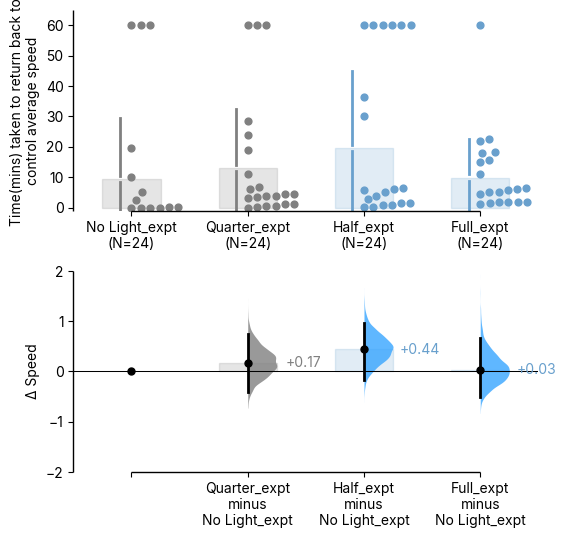

In [370]:
colorpalette = ["gray", "gray",  "#37A5FF", "#37A5FF", "#0083DA", "#0083DA", "#0300B1","#0300B1" ]

db_time = dabest.load(df_rectime, idx=(("No Light_expt", "Quarter_expt", "Half_expt", "Full_expt")))

common_style = {'fontsize_rawxlabel': 10, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

db_time.hedges_g.plot(raw_label= "Time(mins) taken to return back to \ncontrol average speed",
                              contrast_label="Î” Speed", raw_ylim=(-1, 65), contrast_ylim=(-2, 2), custom_palette = colorpalette, **common_style);
